# ModernBERT + LoRA — Dual-Gate: Difficulty & Response Time

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import datetime, os, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr, kendalltau

import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from peft import LoraConfig, TaskType, get_peft_model
from torchmetrics.regression import KendallRankCorrCoef

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}  ({torch.cuda.device_count()} device(s))")
else:
    device = torch.device("cpu")
    print("No GPU available — using CPU.")

use_amp = device.type == "cuda"

GPU: NVIDIA GeForce RTX 5090  (1 device(s))


In [3]:
data_path = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())), "Data", "Our",
    "train_final_extended.csv",
)
dataset = pd.read_csv(data_path)
print(f"Loaded {len(dataset):,} training records.")
print(f"Columns: {list(dataset.columns)}")

Loaded 466 training records.
Columns: ['ItemNum', 'ItemStem_Text', 'Answer__A', 'Answer__B', 'Answer__C', 'Answer__D', 'Answer__E', 'Answer__F', 'Answer__G', 'Answer__H', 'Answer__I', 'Answer__J', 'Answer_Key', 'Answer_Text', 'ItemType', 'EXAM', 'Difficulty', 'Response_Time', 'gemma_thinking', 'gemma_answer', 'gemma_confidence', 'llama_thinking', 'llama_answer', 'llama_confidence', 'answers_input', 'q_answers_input', 'all_input', 'q_a_input', 'llms_a_input', 'q_llms_a_input']


In [4]:
dataset

,ItemNum,ItemStem_Text,Answer__A,Answer__B,Answer__C,Answer__D,Answer__E,Answer__F,Answer__G,Answer__H,...,gemma_confidence,llama_thinking,llama_answer,llama_confidence,answers_input,q_answers_input,all_input,q_a_input,llms_a_input,q_llms_a_input
0,91,"Over 1 year, a study is conducted to assess th...",Case-control study,Crossover study,Open-labeled clinical trial,Randomized clinical trial,"Single-blind, randomized, controlled trial",NaN,NaN,NaN,...,4.0,The study involves patients with chronic myelo...,C,4,Case-control study. Crossover study. Open-labe...,"Over 1 year, a study is conducted to assess th...","Over 1 year, a study is conducted to assess th...","Over 1 year, a study is conducted to assess th...",The study describes a scenario where patients ...,"Over 1 year, a study is conducted to assess th..."
1,288,A previously healthy 52-year-old woman comes t...,Calcitriol production by activated macrophages,Local resorption of bone by metastases,Parathyroid hormone-related peptide secretion,Secretion of parathyroid hormone,Secretion of thyroid-stimulating hormone,NaN,NaN,NaN,...,5.0,Given the patient's symptoms and laboratory fi...,A,4,Calcitriol production by activated macrophages...,A previously healthy 52-year-old woman comes t...,A previously healthy 52-year-old woman comes t...,A previously healthy 52-year-old woman comes t...,The patient presents with hypercalcemia (11.1 ...,A previously healthy 52-year-old woman comes t...
2,160,A 42-year-old woman is brought to the emergenc...,CT scan of the abdomen,CT scan of the chest,Thoracoscopy,Laparotomy,Thoracotomy,NaN,NaN,NaN,...,4.0,Given the patient's presentation with shortnes...,D,4,CT scan of the abdomen. CT scan of the chest. ...,A 42-year-old woman is brought to the emergenc...,A 42-year-old woman is brought to the emergenc...,A 42-year-old woman is brought to the emergenc...,The patient is hemodynamically unstable (BP 80...,A 42-year-old woman is brought to the emergenc...
3,514,A 37-year-old woman comes to the office for a ...,Corticosteroid therapy,Taking frequent breaks from the paper-bleachin...,Undergoing monthly pulmonary function testing,Using a respirator at work,Washing daily after work with a chlorhexidine-...,NaN,NaN,NaN,...,5.0,Given the patient's concern about exposure to ...,D,5,Corticosteroid therapy. Taking frequent breaks...,A 37-year-old woman comes to the office for a ...,A 37-year-old woman comes to the office for a ...,A 37-year-old woman comes to the office for a ...,The patient is asking about occupational expos...,A 37-year-old woman comes to the office for a ...
4,452,A 71-year-old woman comes to the physician bec...,Cellular,Complement,Humoral,Phagocytic cell,Toll-like receptor,NaN,NaN,NaN,...,5.0,The patient's presentation of a painful rash t...,A,5,Cellular. Complement. Humoral. Phagocytic cell...,A 71-year-old woman comes to the physician bec...,A 71-year-old woman comes to the physician bec...,A 71-year-old woman comes to the physician bec...,"The patient presents with a painful, vesicular...",A 71-year-old woman comes to the physician bec...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,362,"An 87-year-old woman, gravida 6, para 6, is br...",Overactive bladder,Overflow incontinence,Stress incontinence,Urinary retention,Urinary tract infection,NaN,NaN,NaN,...,4.0,The patient presents with severe abdominal pai...,D,4,Overactive bladder. Overflow incontinence. Str...,"An 87-year-old woman, gravida 6, para 6, is br...","An 87-year-old woman, gravida 6, para 6, is br...","An 87-year-old woman, gravida 6, para 6, is br...",The patient is an elderly woman presenting wit...,"An 87-year-old woman, gravida 6, para 6, is br..."
462,431,A 52-year-old woman comes to the emergency dep...,Factor replacement therapy,Methotrexate therapy,Plasmapheresis,Prednisone therapy,Splenectomy,NaN,NaN,NaN,...,4.0,Given the patient's presentation of bleeding g...,D,4,Factor replacement therapy. Methotrexate thera...,A 52

# Dataset preprocessing

In [5]:
def fit_minmax_scaler(series):
    """Fit a MinMaxScaler and return (scaled float32 array, fitted scaler)."""
    scaler = MinMaxScaler()
    arr = np.array(series, dtype=np.float32).reshape(-1, 1)
    scaled = scaler.fit_transform(arr).astype(np.float32).flatten()
    return scaled, scaler

In [6]:
STR_COLS = [
    "Answer__A", "Answer__B", "Answer__C", "Answer__D", "Answer__E",
    "Answer__F", "Answer__G", "Answer__H", "Answer__I", "Answer__J",
    "Answer_Key", "Answer_Text", "all_input", "q_answers_input",
    "answers_input", "q_a_input", "llms_a_input", "q_llms_a_input",
    "gemma_thinking", "llama_thinking",
]
dataset[STR_COLS] = dataset[STR_COLS].astype(str)

In [7]:
dataset["Difficulty"],    scaler_difficulty = fit_minmax_scaler(dataset["Difficulty"])
dataset["Response_Time"], scaler_time       = fit_minmax_scaler(dataset["Response_Time"])

In [8]:
fold_1 = dataset.iloc[:92]
fold_2 = dataset.iloc[93:185]
fold_3 = dataset.iloc[186:278]
fold_4 = dataset.iloc[279:371]
fold_5 = dataset.iloc[372:465]

for i, f in enumerate([fold_1, fold_2, fold_3, fold_4, fold_5], 1):
    print(f"fold_{i}: {len(f)} rows")

fold_1: 92 rows
fold_2: 92 rows
fold_3: 92 rows
fold_4: 92 rows
fold_5: 93 rows


# Dual-Gate Model: ModernBERT + LoRA

In [9]:
MODEL_NAME = "answerdotai/ModernBERT-base"
MAX_LEN    = 512
BATCH_SIZE = 16        # reduce to 8 if OOM
EPOCHS     = 10
LR         = 1e-4

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class DualGateModel(torch.nn.Module):
    """Shared ModernBERT encoder with two independent regression heads.

    head_difficulty   → predicts normalised difficulty score  [0, 1]
    head_response_time → predicts normalised response time score [0, 1]

    Both heads receive the [CLS] token representation after the
    LoRA-adapted ModernBERT encoder.
    """

    def __init__(self, encoder: torch.nn.Module, hidden_size: int):
        super().__init__()
        self.encoder            = encoder
        self.head_difficulty    = torch.nn.Linear(hidden_size, 1)
        self.head_response_time = torch.nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]                                # [B, H]
        pred_diff  = torch.sigmoid(self.head_difficulty(cls)).squeeze(-1)   # [B]
        pred_rtime = torch.sigmoid(self.head_response_time(cls)).squeeze(-1) # [B]
        return pred_diff, pred_rtime


def build_model() -> DualGateModel:
    """Load ModernBERT-base, wrap with LoRA adapters, attach dual heads."""
    base = AutoModel.from_pretrained(MODEL_NAME)
    lora_cfg = LoraConfig(
        task_type=TaskType.FEATURE_EXTRACTION,
        r=16,
        lora_alpha=32,
        target_modules="all-linear",
        lora_dropout=0.1,
        bias="none",
    )
    encoder = get_peft_model(base, lora_cfg)
    encoder.print_trainable_parameters()
    return DualGateModel(encoder, base.config.hidden_size)

In [10]:
def encode_texts(texts, max_len: int = MAX_LEN):
    """Batch-tokenise a list/array of strings → (input_ids, attention_mask).

    Uses the `all_input` column which contains the full question + answer text.
    ModernBERT uses RoPE positional embeddings — no token_type_ids needed.
    """
    enc = tokenizer(
        [str(t) for t in texts],
        add_special_tokens=True,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]

In [11]:
def format_time(elapsed: float) -> str:
    """Convert elapsed seconds to hh:mm:ss string."""
    return str(datetime.timedelta(seconds=int(round(elapsed))))

In [12]:
def k_fold_training(df_train: pd.DataFrame, df_val: pd.DataFrame):
    print(f"Train: {len(df_train):,}  |  Validation: {len(df_val):,}")

    ids_tr,  mask_tr  = encode_texts(df_train.all_input.values)
    ids_val, mask_val = encode_texts(df_val.all_input.values)

    y_diff_tr   = torch.tensor(df_train.Difficulty.values.flatten(),    dtype=torch.float32)
    y_rtime_tr  = torch.tensor(df_train.Response_Time.values.flatten(), dtype=torch.float32)
    y_diff_val  = torch.tensor(df_val.Difficulty.values.flatten(),      dtype=torch.float32)
    y_rtime_val = torch.tensor(df_val.Response_Time.values.flatten(),   dtype=torch.float32)

    train_ds = TensorDataset(ids_tr,  mask_tr,  y_diff_tr,  y_rtime_tr)
    val_ds   = TensorDataset(ids_val, mask_val, y_diff_val, y_rtime_val)
    train_dl = DataLoader(train_ds, sampler=RandomSampler(train_ds),
                          batch_size=BATCH_SIZE, num_workers=0)
    val_dl   = DataLoader(val_ds,   sampler=SequentialSampler(val_ds),
                          batch_size=BATCH_SIZE, num_workers=0)

    model      = build_model().to(device)
    optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, eps=1e-8)
    scheduler  = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0,
        num_training_steps=len(train_dl) * EPOCHS,
    )
    criterion       = torch.nn.MSELoss()
    kt_diff_tr      = KendallRankCorrCoef().to(device)
    kt_rtime_tr     = KendallRankCorrCoef().to(device)
    kt_diff_val     = KendallRankCorrCoef().to(device)
    kt_rtime_val    = KendallRankCorrCoef().to(device)
    amp_scaler      = torch.amp.GradScaler("cuda") if use_amp else None

    stats   = []
    t_total = time.time()

    for epoch in range(1, EPOCHS + 1):
        print(f"\n======== Epoch {epoch}/{EPOCHS} ========")
        t0 = time.time()

        # ── Training ──────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        kt_diff_tr.reset(); kt_rtime_tr.reset()

        for ids, mask, lbl_diff, lbl_rtime in train_dl:
            ids, mask = ids.to(device), mask.to(device)
            lbl_diff  = lbl_diff.to(device)
            lbl_rtime = lbl_rtime.to(device)
            model.zero_grad()

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                pred_diff, pred_rtime = model(input_ids=ids, attention_mask=mask)
                loss = (criterion(pred_diff, lbl_diff) +
                        criterion(pred_rtime, lbl_rtime)) * 0.5

            if amp_scaler:
                amp_scaler.scale(loss).backward()
                amp_scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                amp_scaler.step(optimizer)
                amp_scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()
            train_loss += loss.item()
            kt_diff_tr.update(pred_diff.detach(), lbl_diff)
            kt_rtime_tr.update(pred_rtime.detach(), lbl_rtime)

        avg_tr_loss  = train_loss / len(train_dl)
        avg_tr_kdiff = kt_diff_tr.compute().item()
        avg_tr_krt   = kt_rtime_tr.compute().item()
        print(f"  Train  loss: {avg_tr_loss:.4f}  "
              f"Diff τ: {avg_tr_kdiff:.4f}  RTime τ: {avg_tr_krt:.4f}"
              f"  [{format_time(time.time() - t0)}]")

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        kt_diff_val.reset(); kt_rtime_val.reset()

        with torch.no_grad():
            for ids, mask, lbl_diff, lbl_rtime in val_dl:
                ids, mask = ids.to(device), mask.to(device)
                lbl_diff  = lbl_diff.to(device)
                lbl_rtime = lbl_rtime.to(device)
                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    pred_diff, pred_rtime = model(input_ids=ids, attention_mask=mask)
                val_loss += (criterion(pred_diff, lbl_diff) +
                             criterion(pred_rtime, lbl_rtime)).item() * 0.5
                kt_diff_val.update(pred_diff, lbl_diff)
                kt_rtime_val.update(pred_rtime, lbl_rtime)

        avg_val_loss  = val_loss / len(val_dl)
        avg_val_kdiff = kt_diff_val.compute().item()
        avg_val_krt   = kt_rtime_val.compute().item()
        print(f"  Val    loss: {avg_val_loss:.4f}  "
              f"Diff τ: {avg_val_kdiff:.4f}  RTime τ: {avg_val_krt:.4f}")

        stats.append(dict(
            epoch=epoch,
            train_loss=avg_tr_loss,        val_loss=avg_val_loss,
            train_diff_kendall=avg_tr_kdiff,  val_diff_kendall=avg_val_kdiff,
            train_rtime_kendall=avg_tr_krt,   val_rtime_kendall=avg_val_krt,
        ))

    print(f"\nTotal time: {format_time(time.time() - t_total)}")
    return model, pd.DataFrame(stats).set_index("epoch")

In [13]:
# ── Full training on all folds (no held-out validation) ──────────────────────
df_train_all = pd.concat([fold_1, fold_2, fold_3, fold_4, fold_5])
print(f"Total training samples: {len(df_train_all):,}")

ids_tr, mask_tr = encode_texts(df_train_all.all_input.values)
y_diff_tr  = torch.tensor(df_train_all.Difficulty.values.flatten(),    dtype=torch.float32)
y_rtime_tr = torch.tensor(df_train_all.Response_Time.values.flatten(), dtype=torch.float32)

train_ds = TensorDataset(ids_tr, mask_tr, y_diff_tr, y_rtime_tr)
train_dl = DataLoader(
    train_ds,
    sampler=RandomSampler(train_ds),
    batch_size=BATCH_SIZE,
    num_workers=0,
)

model      = build_model().to(device)
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, eps=1e-8)
scheduler  = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=len(train_dl) * EPOCHS,
)
criterion       = torch.nn.MSELoss()
kt_diff_train   = KendallRankCorrCoef().to(device)
kt_rtime_train  = KendallRankCorrCoef().to(device)
amp_scaler      = torch.amp.GradScaler("cuda") if use_amp else None

stats_full = []
t_total    = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\n======== Epoch {epoch}/{EPOCHS} ========")
    t0 = time.time()
    train_loss = 0.0
    kt_diff_train.reset(); kt_rtime_train.reset()
    model.train()

    for ids, mask, lbl_diff, lbl_rtime in train_dl:
        ids, mask = ids.to(device), mask.to(device)
        lbl_diff  = lbl_diff.to(device)
        lbl_rtime = lbl_rtime.to(device)
        model.zero_grad()

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            pred_diff, pred_rtime = model(input_ids=ids, attention_mask=mask)
            loss = (criterion(pred_diff, lbl_diff) +
                    criterion(pred_rtime, lbl_rtime)) * 0.5

        if amp_scaler:
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            amp_scaler.step(optimizer)
            amp_scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()
        train_loss += loss.item()
        kt_diff_train.update(pred_diff.detach(), lbl_diff)
        kt_rtime_train.update(pred_rtime.detach(), lbl_rtime)

    avg_loss   = train_loss / len(train_dl)
    avg_kdiff  = kt_diff_train.compute().item()
    avg_krtime = kt_rtime_train.compute().item()
    print(f"  loss: {avg_loss:.4f}  Diff τ: {avg_kdiff:.4f}  RTime τ: {avg_krtime:.4f}"
          f"  [{format_time(time.time() - t0)}]")
    stats_full.append({
        "epoch": epoch, "train_loss": avg_loss,
        "diff_kendall": avg_kdiff, "rtime_kendall": avg_krtime,
    })

print(f"\nTraining complete — {format_time(time.time() - t_total)}")
df_stats = pd.DataFrame(stats_full).set_index("epoch")
print(df_stats)

Total training samples: 461


Total training samples: 461


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

Total training samples: 461


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 3,379,200 || all params: 152,393,472 || trainable%: 2.2174

======== Epoch 1/10 ========


/tmp/ipykernel_96874/3724823837.py:61: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  loss: 0.0457  Diff τ: 0.0155  RTime τ: -0.0367  [0:00:03]

======== Epoch 2/10 ========
  loss: 0.0352  Diff τ: 0.0302  RTime τ: 0.1912  [0:00:02]

======== Epoch 3/10 ========
  loss: 0.0331  Diff τ: 0.1355  RTime τ: 0.3104  [0:00:02]

======== Epoch 4/10 ========
  loss: 0.0312  Diff τ: 0.1887  RTime τ: 0.3482  [0:00:02]

======== Epoch 5/10 ========
  loss: 0.0297  Diff τ: 0.2194  RTime τ: 0.4000  [0:00:02]

======== Epoch 6/10 ========
  loss: 0.0288  Diff τ: 0.2361  RTime τ: 0.4454  [0:00:02]

======== Epoch 7/10 ========
  loss: 0.0271  Diff τ: 0.2947  RTime τ: 0.4597  [0:00:02]

======== Epoch 8/10 ========
  loss: 0.0263  Diff τ: 0.3075  RTime τ: 0.4574  [0:00:02]

======== Epoch 9/10 ========
  loss: 0.0246  Diff τ: 0.3436  RTime τ: 0.4959  [0:00:02]

======== Epoch 10/10 ========
  loss: 0.0244  Diff τ: 0.3540  RTime τ: 0.4983  [0:00:02]

Training complete — 0:00:24
       train_loss  diff_kendall  rtime_kendall
epoch                                         
1        0.0457

# Evaluate on test set


In [14]:
test_data_path = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())), "Data", "Our",
    "test_final_extended.csv",
)
test_df = pd.read_csv(test_data_path)
print(f"Loaded {len(test_df):,} test records.")
print(f"Columns: {list(test_df.columns)}")

Loaded 201 test records.
Columns: ['ItemNum', 'ItemStem_Text', 'Answer__A', 'Answer__B', 'Answer__C', 'Answer__D', 'Answer__E', 'Answer__F', 'Answer__G', 'Answer__H', 'Answer__I', 'Answer__J', 'Answer_Key', 'Answer_Text', 'ItemType', 'EXAM', 'gemma_thinking', 'gemma_answer', 'gemma_confidence', 'llama_thinking', 'llama_answer', 'llama_confidence', 'answers_input', 'q_answers_input', 'all_input', 'q_a_input', 'llms_a_input', 'q_llms_a_input', 'Difficulty', 'Response_Time']


In [15]:
test_df

,ItemNum,ItemStem_Text,Answer__A,Answer__B,Answer__C,Answer__D,Answer__E,Answer__F,Answer__G,Answer__H,...,llama_answer,llama_confidence,answers_input,q_answers_input,all_input,q_a_input,llms_a_input,q_llms_a_input,Difficulty,Response_Time
0,552,A 78-year-old woman undergoes an outpatient la...,Gastroduodenal,Left gastric,Left hepatic,Right gastric,Right hepatic,NaN,NaN,NaN,...,E,5,Gastroduodenal. Left gastric. Left hepatic. Ri...,A 78-year-old woman undergoes an outpatient la...,A 78-year-old woman undergoes an outpatient la...,A 78-year-old woman undergoes an outpatient la...,"Okay, I need to recall the anatomy of the cyst...",A 78-year-old woman undergoes an outpatient la...,0.52,75.21
1,16,A 48-year-old man dies suddenly of a cardiac a...,Acute inflammation,Fibrinous exudate,Fibrous scar,Granulation tissue,Normal kidney,NaN,NaN,NaN,...,C,4,Acute inflammation. Fibrinous exudate. Fibrous...,A 48-year-old man dies suddenly of a cardiac a...,A 48-year-old man dies suddenly of a cardiac a...,A 48-year-old man dies suddenly of a cardiac a...,The patient experienced an episode of oliguric...,A 48-year-old man dies suddenly of a cardiac a...,0.70,80.88
2,441,A study is being conducted to assess mesotheli...,Address confounding,Demonstrate causality,Minimize ascertainment bias,Reduce recall bias,NaN,NaN,NaN,NaN,...,C,4,Address confounding. Demonstrate causality. Mi...,A study is being conducted to assess mesotheli...,A study is being conducted to assess mesotheli...,A study is being conducted to assess mesotheli...,The study design is a case-control study (enro...,A study is being conducted to assess mesotheli...,0.84,88.45
3,219,A 68-year-old man comes to the office because ...,Age,Gender,History of osteoarthritis,Previous occupation,Use of pravastatin,NaN,NaN,NaN,...,A,5,Age. Gender. History of osteoarthritis. Previo...,A 68-year-old man comes to the office because ...,A 68-year-old man comes to the office because ...,A 68-year-old man comes to the office because ...,The patient is an elderly man (68) presenting ...,A 68-year-old man comes to the office because ...,1.02,127.30
4,600,A 20-year-old woman is brought to the urgent c...,Diet,Family illness,Recent travel,Trauma,Unintended weight loss,NaN,NaN,NaN,...,B,4,Diet. Family illness. Recent travel. Trauma. U...,A 20-year-old woman is brought to the urgent c...,A 20-year-old woman is brought to the urgent c...,A 20-year-old woman is brought to the urgent c...,The patient is a 20-year-old woman presenting ...,A 20-year-old woman is brought to the urgent c...,0.96,88.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,612,A 45-year-old man is brought to the clinic by ...,Atrophy,Decreased visual acuity,Loss of proprioception,Presence of palmomental reflex,Ptosis,NaN,NaN,NaN,...,A,4,Atrophy. Decreased visual acuity. Loss of prop...,A 45-year-old man is brought to the clinic by ...,A 45-year-old man is brought to the clinic by ...,A 45-year-old man is brought to the clinic by ...,The patient presents with progressive weakness...,A 45-year-old man is brought to the clinic by ...,0.22,95.17
197,315,A 64-year-old man with non-Hodgkin lymphoma co...,Bleomycin,Cyclophosphamide,Cytarabine,Doxorubicin,Fluorouracil,Methotrexate,Vincristine,NaN,...,G,5,Bleomycin. Cyclophosphamide. Cytarabine. Doxor...,A 64-year-old man with non-Hodgkin lymphoma co...,A 64-year-old man with non-Hodgkin lymphoma co...,A 64-year-old man with non-Hodgkin lymphoma co...,The patient is presenting with progressive num...,A 64-year-old man with non-Hodgkin lymphoma co...,0.14,42.72
198,509,A 9-month-old boy is brought to the office by ...,Abdominal ultrasonography,Anti-Saccharomyces cerevisiae antibody testing,Nitroblue tetrazolium testing,Rectal swab for group B streptococcus,Skeletal survey,Stool culture for Salmonella enteritidis,NaN,NaN,...,E,4,Abdominal ultrasonography. Anti-Saccharomyces ...,A 9-month-old boy is brought to the office by ...,A 9-month-old boy is brough

In [16]:
test_df[STR_COLS] = test_df[STR_COLS].astype(str)

In [17]:
# Test set has no ground-truth labels — inference only
has_test_labels = ("Difficulty" in test_df.columns and "Response_Time" in test_df.columns)
print(f"Test set has ground-truth labels: {has_test_labels}")

Test set has ground-truth labels: True


In [18]:
if has_test_labels:
    labels_test_diff  = torch.tensor(
        scaler_difficulty.transform(
            np.array(test_df["Difficulty"], dtype=np.float32).reshape(-1, 1)
        ).flatten(), dtype=torch.float32)
    labels_test_rtime = torch.tensor(
        scaler_time.transform(
            np.array(test_df["Response_Time"], dtype=np.float32).reshape(-1, 1)
        ).flatten(), dtype=torch.float32)
else:
    # Placeholder zero tensors; loss won't be computed
    labels_test_diff  = torch.zeros(len(test_df), dtype=torch.float32)
    labels_test_rtime = torch.zeros(len(test_df), dtype=torch.float32)

In [19]:
test_df

,ItemNum,ItemStem_Text,Answer__A,Answer__B,Answer__C,Answer__D,Answer__E,Answer__F,Answer__G,Answer__H,...,llama_answer,llama_confidence,answers_input,q_answers_input,all_input,q_a_input,llms_a_input,q_llms_a_input,Difficulty,Response_Time
0,552,A 78-year-old woman undergoes an outpatient la...,Gastroduodenal,Left gastric,Left hepatic,Right gastric,Right hepatic,NaN,NaN,NaN,...,E,5,Gastroduodenal. Left gastric. Left hepatic. Ri...,A 78-year-old woman undergoes an outpatient la...,A 78-year-old woman undergoes an outpatient la...,A 78-year-old woman undergoes an outpatient la...,"Okay, I need to recall the anatomy of the cyst...",A 78-year-old woman undergoes an outpatient la...,0.52,75.21
1,16,A 48-year-old man dies suddenly of a cardiac a...,Acute inflammation,Fibrinous exudate,Fibrous scar,Granulation tissue,Normal kidney,NaN,NaN,NaN,...,C,4,Acute inflammation. Fibrinous exudate. Fibrous...,A 48-year-old man dies suddenly of a cardiac a...,A 48-year-old man dies suddenly of a cardiac a...,A 48-year-old man dies suddenly of a cardiac a...,The patient experienced an episode of oliguric...,A 48-year-old man dies suddenly of a cardiac a...,0.70,80.88
2,441,A study is being conducted to assess mesotheli...,Address confounding,Demonstrate causality,Minimize ascertainment bias,Reduce recall bias,NaN,NaN,NaN,NaN,...,C,4,Address confounding. Demonstrate causality. Mi...,A study is being conducted to assess mesotheli...,A study is being conducted to assess mesotheli...,A study is being conducted to assess mesotheli...,The study design is a case-control study (enro...,A study is being conducted to assess mesotheli...,0.84,88.45
3,219,A 68-year-old man comes to the office because ...,Age,Gender,History of osteoarthritis,Previous occupation,Use of pravastatin,NaN,NaN,NaN,...,A,5,Age. Gender. History of osteoarthritis. Previo...,A 68-year-old man comes to the office because ...,A 68-year-old man comes to the office because ...,A 68-year-old man comes to the office because ...,The patient is an elderly man (68) presenting ...,A 68-year-old man comes to the office because ...,1.02,127.30
4,600,A 20-year-old woman is brought to the urgent c...,Diet,Family illness,Recent travel,Trauma,Unintended weight loss,NaN,NaN,NaN,...,B,4,Diet. Family illness. Recent travel. Trauma. U...,A 20-year-old woman is brought to the urgent c...,A 20-year-old woman is brought to the urgent c...,A 20-year-old woman is brought to the urgent c...,The patient is a 20-year-old woman presenting ...,A 20-year-old woman is brought to the urgent c...,0.96,88.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,612,A 45-year-old man is brought to the clinic by ...,Atrophy,Decreased visual acuity,Loss of proprioception,Presence of palmomental reflex,Ptosis,NaN,NaN,NaN,...,A,4,Atrophy. Decreased visual acuity. Loss of prop...,A 45-year-old man is brought to the clinic by ...,A 45-year-old man is brought to the clinic by ...,A 45-year-old man is brought to the clinic by ...,The patient presents with progressive weakness...,A 45-year-old man is brought to the clinic by ...,0.22,95.17
197,315,A 64-year-old man with non-Hodgkin lymphoma co...,Bleomycin,Cyclophosphamide,Cytarabine,Doxorubicin,Fluorouracil,Methotrexate,Vincristine,NaN,...,G,5,Bleomycin. Cyclophosphamide. Cytarabine. Doxor...,A 64-year-old man with non-Hodgkin lymphoma co...,A 64-year-old man with non-Hodgkin lymphoma co...,A 64-year-old man with non-Hodgkin lymphoma co...,The patient is presenting with progressive num...,A 64-year-old man with non-Hodgkin lymphoma co...,0.14,42.72
198,509,A 9-month-old boy is brought to the office by ...,Abdominal ultrasonography,Anti-Saccharomyces cerevisiae antibody testing,Nitroblue tetrazolium testing,Rectal swab for group B streptococcus,Skeletal survey,Stool culture for Salmonella enteritidis,NaN,NaN,...,E,4,Abdominal ultrasonography. Anti-Saccharomyces ...,A 9-month-old boy is brought to the office by ...,A 9-month-old boy is brough

In [20]:
ids_test, mask_test = encode_texts(test_df.all_input.values)
item_nums_test = torch.tensor(test_df.ItemNum.values, dtype=torch.long)

test_ds = TensorDataset(ids_test, mask_test, item_nums_test,
                        labels_test_diff, labels_test_rtime)

In [21]:
test_dl = DataLoader(test_ds, sampler=SequentialSampler(test_ds), batch_size=BATCH_SIZE)

In [22]:
print(f"Predicting for {len(ids_test):,} test samples …")

model.eval()
all_preds_diff  = []
all_preds_rtime = []
all_item_nums   = []

with torch.no_grad():
    for ids, mask, item_nums, *_ in test_dl:   # labels ignored (may be zero placeholders)
        ids, mask = ids.to(device), mask.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            pred_diff, pred_rtime = model(input_ids=ids, attention_mask=mask)
        all_preds_diff.extend(pred_diff.cpu().numpy())
        all_preds_rtime.extend(pred_rtime.cpu().numpy())
        all_item_nums.extend(item_nums.numpy())

print("Done.")

Predicting for 201 test samples …
Done.


In [23]:
preds_diff  = scaler_difficulty.inverse_transform(
    np.array(all_preds_diff).reshape(-1, 1)).flatten()
preds_rtime = scaler_time.inverse_transform(
    np.array(all_preds_rtime).reshape(-1, 1)).flatten()
item_nums   = np.array(all_item_nums, dtype=int)

In [24]:
df_out = pd.DataFrame({
    "ItemNum":                item_nums,
    "Difficulty_Prediction":  preds_diff,
    "ResponseTime_Prediction": preds_rtime,
})
df_out

/home/bojingyy/CSEN 346/Automated-Item-Difficulty-Prediction/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,ItemNum,Difficulty_Prediction,ResponseTime_Prediction
0,552,0.280518,59.46875
1,16,0.522949,85.68750
2,441,0.737793,104.18750
3,219,0.570801,97.50000
4,600,0.364502,63.37500
...,...,...,...
196,612,0.360596,76.37500
197,315,0.347412,64.18750
198,509,0.559570,72.75000
199,550,0.566895,113.37500


In [25]:
df_out.to_csv("Unibuc-FMI_DualGate_predictions.csv", index=False)

=== Test Set Evaluation ===

  [Difficulty]
    RMSE      : 0.3203
    Pearson r : 0.1359  (p=5.44e-02)
    Kendall τ : 0.0780  (p=1.04e-01)

  [Response Time]
    RMSE      : 27.7005
    Pearson r : 0.4883  (p=1.92e-13)
    Kendall τ : 0.3703  (p=6.16e-15)


=== Test Set Evaluation ===

  [Difficulty]
    RMSE      : 0.3203
    Pearson r : 0.1359  (p=5.44e-02)
    Kendall τ : 0.0780  (p=1.04e-01)

  [Response Time]
    RMSE      : 27.7005
    Pearson r : 0.4883  (p=1.92e-13)
    Kendall τ : 0.3703  (p=6.16e-15)


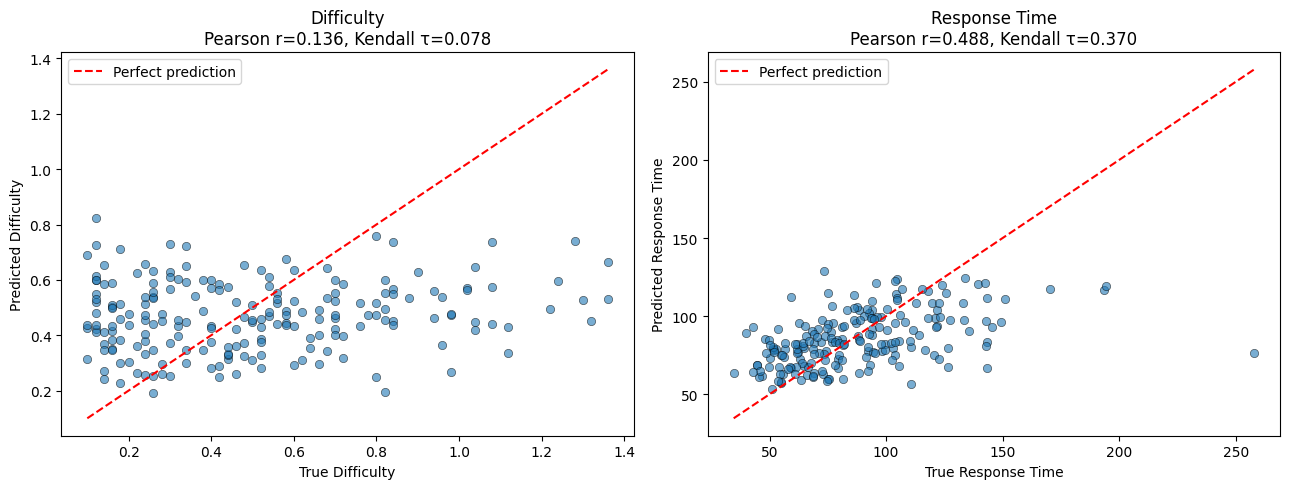

In [26]:
if not has_test_labels:
    print("No ground-truth labels available for the test set — skipping metrics.")
else:
    true_diff  = scaler_difficulty.inverse_transform(
        labels_test_diff.numpy().reshape(-1, 1)).flatten()
    true_rtime = scaler_time.inverse_transform(
        labels_test_rtime.numpy().reshape(-1, 1)).flatten()

    def _metrics(true, pred, name):
        mse          = mean_squared_error(true, pred)
        r,   rp      = pearsonr(true, pred)
        tau, taup    = kendalltau(true, pred)
        print(f"\n  [{name}]")
        print(f"    RMSE      : {np.sqrt(mse):.4f}")
        print(f"    Pearson r : {r:.4f}  (p={rp:.2e})")
        print(f"    Kendall τ : {tau:.4f}  (p={taup:.2e})")
        return r, tau

    print("=== Test Set Evaluation ===")
    r_d,   tau_d   = _metrics(true_diff,  preds_diff,  "Difficulty")
    r_r,   tau_r   = _metrics(true_rtime, preds_rtime, "Response Time")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, true, pred, name, r, tau in [
        (axes[0], true_diff,  preds_diff,  "Difficulty",    r_d,   tau_d),
        (axes[1], true_rtime, preds_rtime, "Response Time", r_r,   tau_r),
    ]:
        ax.scatter(true, pred, alpha=0.6, edgecolors="k", linewidths=0.5)
        lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
        ax.plot(lims, lims, "r--", label="Perfect prediction")
        ax.set_xlabel(f"True {name}")
        ax.set_ylabel(f"Predicted {name}")
        ax.set_title(f"{name}\nPearson r={r:.3f}, Kendall τ={tau:.3f}")
        ax.legend()

    plt.tight_layout()
    plt.show()